# N-pulse LMT sequence

Explicit N-pulse sequence with:
- π/2 beam splitter at +1× recoil detuning
- N π pulses to accelerate the top arm
- N π pulses to decelerate the top arm (reverse order)
- π mirror pulse at +1× recoil detuning
- N π pulses to accelerate the bottom arm
- N π pulses to decelerate the bottom arm (reverse order)
- final π/2 recombiner at +1× recoil detuning


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, '..')

import matplotlib.pyplot as plt
import lmt_sim.lmt_simulation as sim
import lmt_sim.lmt_sequence as seq
import version_info as vs
import numpy as np

In [2]:
N = 4
RABI_FREQ = 1*sim.RABI_FREQ
T_PI = 0.5 / RABI_FREQ

sequence = []

# 1) Beam splitter
sequence.append(
    seq.Pulse(
        k=+1,
        detuning_hz=+1 * sim.RECOIL_FREQUENCY_HZ,
        phi=0.0,
        label="BS pi/2",
        rabi_frequency=RABI_FREQ,
        duration=T_PI / 2,
    )
)

# 2) Accelerate top arm: (+1, -3, +5, -7, ...)
top_accel = []
for i in range(N):
    k = -1 if i % 2 == 0 else +1
    detuning_mult = (-1 if i % 2 == 0 else +1) * (2 * (i + 1) + 1)
    top_accel.append((k, detuning_mult))
    sequence.append(
        seq.Pulse(
            k=k,
            detuning_hz=detuning_mult * sim.RECOIL_FREQUENCY_HZ,
            phi=0.0,
            label=f"top accel {i+1}",
            rabi_frequency=RABI_FREQ,
            duration=T_PI,
        )
    )

# 3) Decelerate top arm: reverse of top acceleration
for i, (k, detuning_mult) in enumerate(reversed(top_accel), start=1):
    sequence.append(
        seq.Pulse(
            k=k,
            detuning_hz=detuning_mult * sim.RECOIL_FREQUENCY_HZ,
            phi=0.0,
            label=f"top decel {i}",
            rabi_frequency=RABI_FREQ,
            duration=T_PI,
        )
    )

# 4) Mirror pulse
sequence.append(
    seq.Pulse(
        k=+1,
        detuning_hz=+1 * sim.RECOIL_FREQUENCY_HZ,
        phi=0.0,
        label="mirror pi",
        rabi_frequency=RABI_FREQ,
        duration=T_PI,
    )
)

# 5) Accelerate bottom arm: (-1, +3, -5, +7, ...), starting with k=-1
bottom_accel = []
for i in range(N):
    k = -1 if i % 2 == 0 else +1
    detuning_mult = (-1 if i % 2 == 0 else +1) * (2 * (i + 1) + 1)
    bottom_accel.append((k, detuning_mult))
    sequence.append(
        seq.Pulse(
            k=k,
            detuning_hz=detuning_mult * sim.RECOIL_FREQUENCY_HZ,
            phi=0.0,
            label=f"bottom accel {i+1}",
            rabi_frequency=RABI_FREQ,
            duration=T_PI,
        )
    )

# 6) Decelerate bottom arm: reverse of bottom acceleration
for i, (k, detuning_mult) in enumerate(reversed(bottom_accel), start=1):
    sequence.append(
        seq.Pulse(
            k=k,
            detuning_hz=detuning_mult * sim.RECOIL_FREQUENCY_HZ,
            phi=0.0,
            label=f"bottom decel {i}",
            rabi_frequency=RABI_FREQ,
            duration=T_PI,
        )
    )

# 7) Final recombiner
sequence.append(
    seq.Pulse(
        k=+1,
        detuning_hz=+1 * sim.RECOIL_FREQUENCY_HZ,
        phi=0.0,
        label="BS pi/2 final",
        rabi_frequency=RABI_FREQ,
        duration=T_PI / 2,
    )
)

# Freefall just for visibility
sequence.append(
    seq.Freefall(
        duration=T_PI,
        label="freefall",
    )
)


print(f"N = {N}")
print(f"Total pulses = {len(sequence)}")
for i, pulse in enumerate(sequence, start=1):
    if hasattr(pulse, "detuning_hz") and hasattr(pulse, "k"):
        detuning_mult = pulse.detuning_hz / sim.RECOIL_FREQUENCY_HZ
    else:
        print(f"{i:02d}. {pulse.label:14s} freefall, duration={pulse.duration:.3e} s")
        continue
    pulse_kind = "pi/2" if abs(pulse.duration - T_PI / 2) < 1e-15 else "pi"
    print(
        f"{i:02d}. {pulse.label:14s} k={pulse.k:+d}, detuning={detuning_mult:+.0f} x recoil, {pulse_kind}"
    )

N = 4
Total pulses = 20
01. BS pi/2        k=+1, detuning=+1 x recoil, pi/2
02. top accel 1    k=-1, detuning=-3 x recoil, pi
03. top accel 2    k=+1, detuning=+5 x recoil, pi
04. top accel 3    k=-1, detuning=-7 x recoil, pi
05. top accel 4    k=+1, detuning=+9 x recoil, pi
06. top decel 1    k=+1, detuning=+9 x recoil, pi
07. top decel 2    k=-1, detuning=-7 x recoil, pi
08. top decel 3    k=+1, detuning=+5 x recoil, pi
09. top decel 4    k=-1, detuning=-3 x recoil, pi
10. mirror pi      k=+1, detuning=+1 x recoil, pi
11. bottom accel 1 k=-1, detuning=-3 x recoil, pi
12. bottom accel 2 k=+1, detuning=+5 x recoil, pi
13. bottom accel 3 k=-1, detuning=-7 x recoil, pi
14. bottom accel 4 k=+1, detuning=+9 x recoil, pi
15. bottom decel 1 k=+1, detuning=+9 x recoil, pi
16. bottom decel 2 k=-1, detuning=-7 x recoil, pi
17. bottom decel 3 k=+1, detuning=+5 x recoil, pi
18. bottom decel 4 k=-1, detuning=-3 x recoil, pi
19. BS pi/2 final  k=+1, detuning=+1 x recoil, pi/2
20. freefall       fre

Clouds: 4
Clearouts: 0


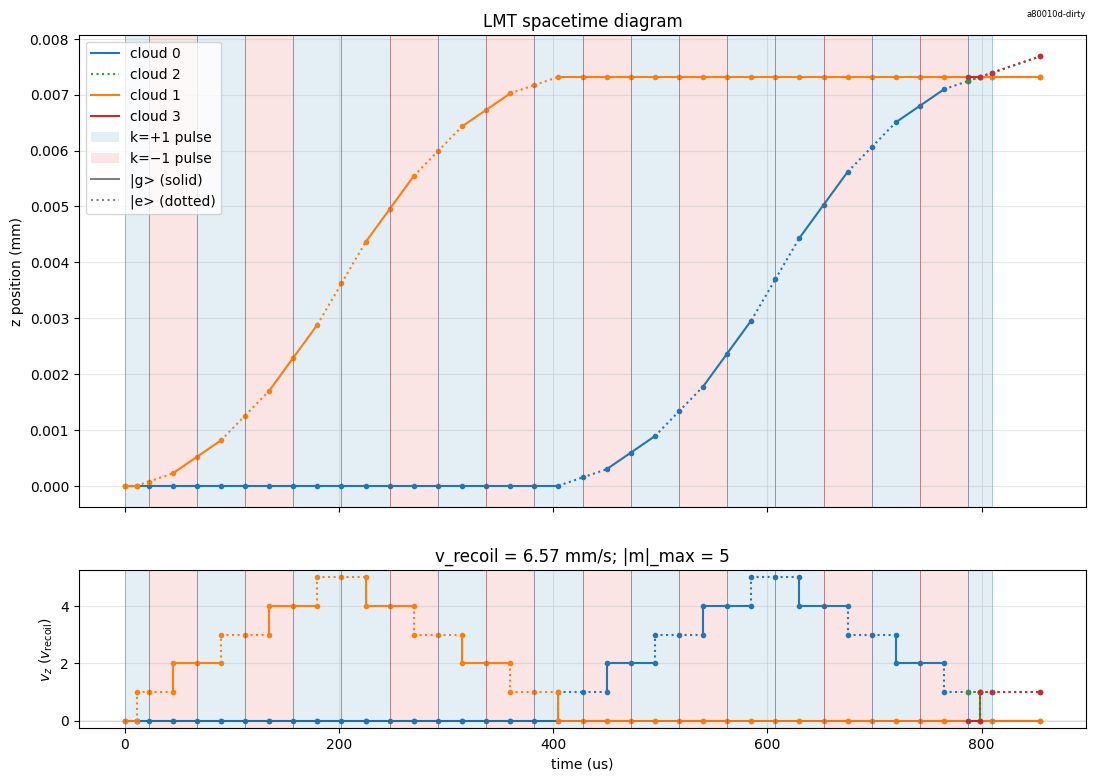

In [3]:
clouds, clearout_times = seq.compute_spacetime_trajectory(sequence, plot=True)
print(f'Clouds: {len(clouds)}')
print(f'Clearouts: {len(clearout_times)}')

vs.tag_plot(small=True);

In [4]:
state = sim.make_atom_states(
    position_x=0.0,
    position_y=0.0,
    position_z=0.0,
    initial_velocity_z=0.0,
    c0=1.0,
    c1=0.0,
)

result = seq.run_pulse_sequence_in_lab_frame(state, pulse_sequence=sequence, discard_threshold=1e-9)
if result is None:
    raise RuntimeError('Atom was cleared out by the sequence')

state, _, _ = result
ground_prob, excited_prob = sim.calculate_ground_and_excited_probabilities(state)

print(f'Ground probability:  {ground_prob:.6f}')
print(f'Excited probability: {excited_prob:.6f}')


print(f'Excited fraction:    {excited_prob / (ground_prob + excited_prob):.6f}')

Ground probability:  0.975373
Excited probability: 0.024393
Excited fraction:    0.024398


In [5]:
def get_sequence(N, phi):

    sequence = []

    # 1) Beam splitter
    sequence.append(
        seq.Pulse(
            k=+1,
            detuning_hz=+1 * sim.RECOIL_FREQUENCY_HZ,
            phi=0.0,
            label="BS pi/2",
            rabi_frequency=RABI_FREQ,
            duration=T_PI / 2,
        )
    )

    # 2) Accelerate top arm: (+1, -3, +5, -7, ...)
    top_accel = []
    for i in range(N):
        k = -1 if i % 2 == 0 else +1
        detuning_mult = (-1 if i % 2 == 0 else +1) * (2 * (i + 1) + 1)
        top_accel.append((k, detuning_mult))
        sequence.append(
            seq.Pulse(
                k=k,
                detuning_hz=detuning_mult * sim.RECOIL_FREQUENCY_HZ,
                phi=0.0,
                label=f"top accel {i+1}",
                rabi_frequency=RABI_FREQ,
                duration=T_PI,
            )
        )

    # 3) Decelerate top arm: reverse of top acceleration
    for i, (k, detuning_mult) in enumerate(reversed(top_accel), start=1):
        sequence.append(
            seq.Pulse(
                k=k,
                detuning_hz=detuning_mult * sim.RECOIL_FREQUENCY_HZ,
                phi=0.0,
                label=f"top decel {i}",
                rabi_frequency=RABI_FREQ,
                duration=T_PI,
            )
        )

    # 4) Mirror pulse
    sequence.append(
        seq.Pulse(
            k=+1,
            detuning_hz=+1 * sim.RECOIL_FREQUENCY_HZ,
            phi=phi,
            label="mirror pi",
            rabi_frequency=RABI_FREQ,
            duration=T_PI,
        )
    )

    # 5) Accelerate bottom arm: (-1, +3, -5, +7, ...), starting with k=-1
    bottom_accel = []
    for i in range(N):
        k = -1 if i % 2 == 0 else +1
        detuning_mult = (-1 if i % 2 == 0 else +1) * (2 * (i + 1) + 1)
        bottom_accel.append((k, detuning_mult))
        sequence.append(
            seq.Pulse(
                k=k,
                detuning_hz=detuning_mult * sim.RECOIL_FREQUENCY_HZ,
                phi=phi,
                label=f"bottom accel {i+1}",
                rabi_frequency=RABI_FREQ,
                duration=T_PI,
            )
        )

    # 6) Decelerate bottom arm: reverse of bottom acceleration
    for i, (k, detuning_mult) in enumerate(reversed(bottom_accel), start=1):
        sequence.append(
            seq.Pulse(
                k=k,
                detuning_hz=detuning_mult * sim.RECOIL_FREQUENCY_HZ,
                phi=phi,
                label=f"bottom decel {i}",
                rabi_frequency=RABI_FREQ,
                duration=T_PI,
            )
        )

    # 7) Final recombiner
    sequence.append(
        seq.Pulse(
            k=+1,
            detuning_hz=+1 * sim.RECOIL_FREQUENCY_HZ,
            phi=phi * 4,
            label="BS pi/2 final",
            rabi_frequency=RABI_FREQ,
            duration=T_PI / 2,
        )
    )

    # Freefall just for visibility
    sequence.append(
        seq.Freefall(
            duration=T_PI,
            label="freefall",
        )
    )

    return sequence

In [6]:
from joblib import Parallel, delayed
from tqdm import tqdm

phis = np.linspace(0, 2 * np.pi, 100)
N_LMTs = 4

initial_state = sim.make_atom_states(
    position_x=0.0,
    position_y=0.0,
    position_z=0.0,
    initial_velocity_z=0.0,
    c0=1.0,
    c1=0.0,
)


def run_phi(phi):
    sequence = get_sequence(N=N_LMTs, phi=phi)
    result = seq.run_pulse_sequence_in_lab_frame(
        initial_state,
        pulse_sequence=sequence,
        discard_threshold=1e-9,
    )
    if result is None:
        raise RuntimeError('Atom was cleared out by the sequence')
    state, _, _ = result
    ground_prob, excited_prob = sim.calculate_ground_and_excited_probabilities(state)
    return excited_prob / (ground_prob + excited_prob)


excitations = Parallel(n_jobs=-1)(
    delayed(run_phi)(phi) for phi in tqdm(phis, desc='phi')
)

phi:   0%|          | 0/100 [00:00<?, ?it/s]

phi:   8%|▊         | 8/100 [00:00<00:07, 11.63it/s]

phi:  12%|█▏        | 12/100 [00:01<00:09,  9.11it/s]

phi:  16%|█▌        | 16/100 [00:01<00:08,  9.46it/s]

phi:  20%|██        | 20/100 [00:02<00:08,  9.22it/s]

...

phi:  88%|████████▊ | 88/100 [00:08<00:01, 10.93it/s]

phi:  92%|█████████▏| 92/100 [00:08<00:00, 10.81it/s]

phi:  96%|█████████▌| 96/100 [00:09<00:00, 10.33it/s]

phi: 100%|██████████| 100/100 [00:09<00:00, 10.21it/s]

phi: 100%|██████████| 100/100 [00:09<00:00, 10.33it/s]

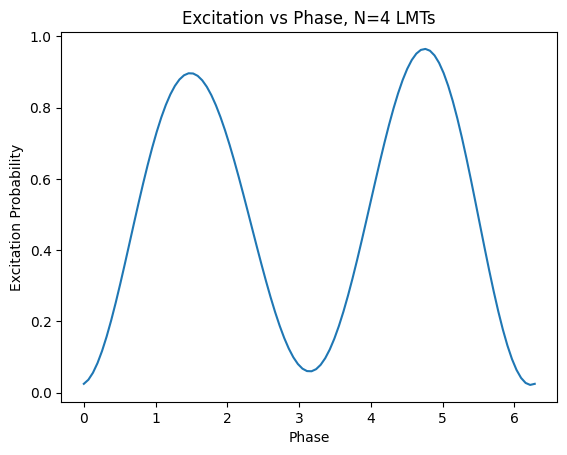

In [7]:
plt.plot(phis, excitations)  # type: ignore
plt.xlabel('Phase')
plt.ylabel('Excitation Probability')
plt.title(f'Excitation vs Phase, N={N_LMTs} LMTs');

We should get perfect fringes. At what pulse are we messing it up?


In [8]:
full_sequence = get_sequence(N=6, phi=np.pi / 4)
n_steps = len(full_sequence) + 1  # i = 0..len(sequence)


def make_initial_state():
    return sim.make_atom_states(
        position_x=0.0,
        position_y=0.0,
        position_z=0.0,
        initial_velocity_z=0.0,
        c0=1.0,
        c1=0.0,
    )


def populations_by_m(state):
    m_vals = state.m_values
    amps = state.amplitudes
    is_ground = state.internal_is_ground
    pop = np.abs(amps) ** 2

    g = {}
    e = {}
    for m in np.unique(m_vals):
        mask_m = m_vals == m
        g[int(m)] = float(pop[mask_m & is_ground].sum())
        e[int(m)] = float(pop[mask_m & (~is_ground)].sum())
    return g, e


g_steps = []
e_steps = []
all_m = set()

for i in range(n_steps):
    state0 = make_initial_state()

    if i == 0:
        state_i = state0
    else:
        result = seq.run_pulse_sequence_in_lab_frame(
            state0,
            pulse_sequence=full_sequence[:i],
            discard_threshold=1e-9,
        )
        if result is None:
            raise RuntimeError(f"Atom was cleared out at step i={i}")
        state_i, _, _ = result

    g_i, e_i = populations_by_m(state_i)
    g_steps.append(g_i)
    e_steps.append(e_i)
    all_m.update(g_i.keys())
    all_m.update(e_i.keys())

m_all = np.array(sorted(all_m), dtype=int)

Total events in full sequence: 28
Swept i from 0 to 28


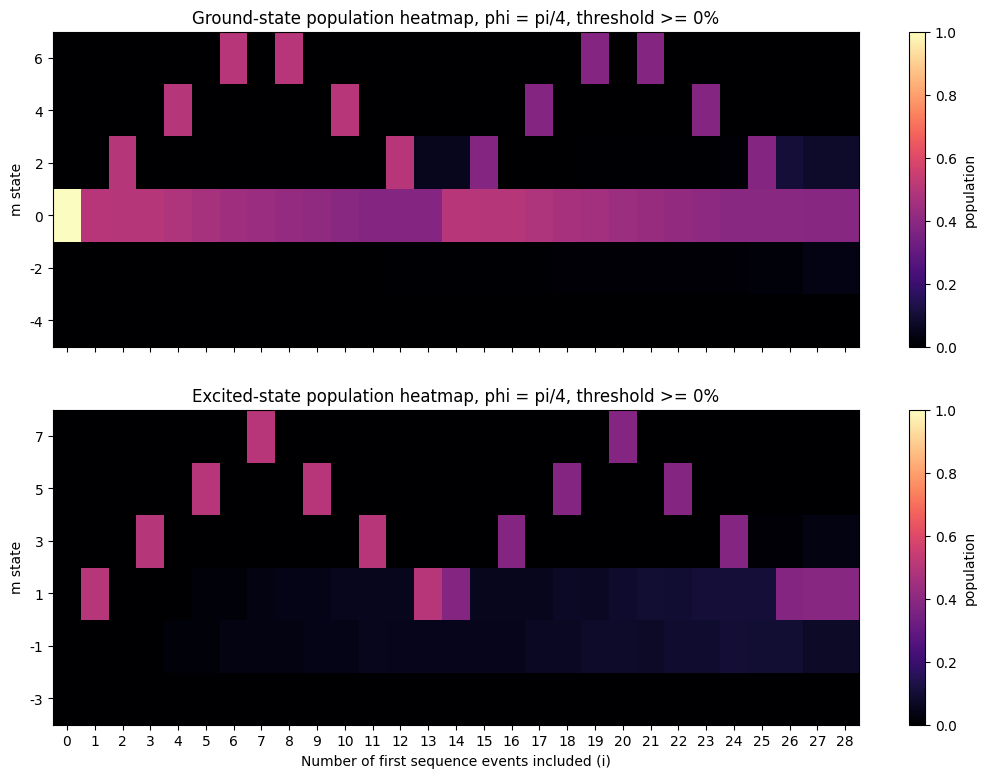

In [9]:

grid_g = np.zeros((len(m_all), n_steps), dtype=float)
grid_e = np.zeros((len(m_all), n_steps), dtype=float)

for t in range(n_steps):
    for r, m in enumerate(m_all):
        grid_g[r, t] = g_steps[t].get(int(m), 0.0)
        grid_e[r, t] = e_steps[t].get(int(m), 0.0)

threshold = 0.0001
g_keep = grid_g.max(axis=1) >= threshold
e_keep = grid_e.max(axis=1) >= threshold

x = np.arange(n_steps)

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)


def plot_heat(ax, grid, keep_mask, title):
    if keep_mask.any():
        shown = grid[keep_mask, :]
        y_labels = m_all[keep_mask]
        im = ax.imshow(
            shown,
            origin='lower',
            aspect='auto',
            interpolation='nearest',
            cmap='magma',
            vmin=0.0,
            vmax=1.0,
        )
        ax.set_yticks(np.arange(len(y_labels)))
        ax.set_yticklabels(y_labels)
        fig.colorbar(im, ax=ax, label='population')
    else:
        ax.text(0.5, 0.5, 'No m-state exceeds threshold', ha='center', va='center', transform=ax.transAxes)
        ax.set_yticks([])

    ax.set_ylabel('m state')
    ax.set_title(title)


plot_heat(
    axes[0],
    grid_g,
    g_keep,
    f'Ground-state population heatmap, phi = pi/4, threshold >= {threshold:.0%}',
)
plot_heat(
    axes[1],
    grid_e,
    e_keep,
    f'Excited-state population heatmap, phi = pi/4, threshold >= {threshold:.0%}',
)

axes[1].set_xlabel('Number of first sequence events included (i)')
axes[1].set_xticks(x)

print(f'Total events in full sequence: {len(full_sequence)}')
print(f'Swept i from 0 to {len(full_sequence)}')

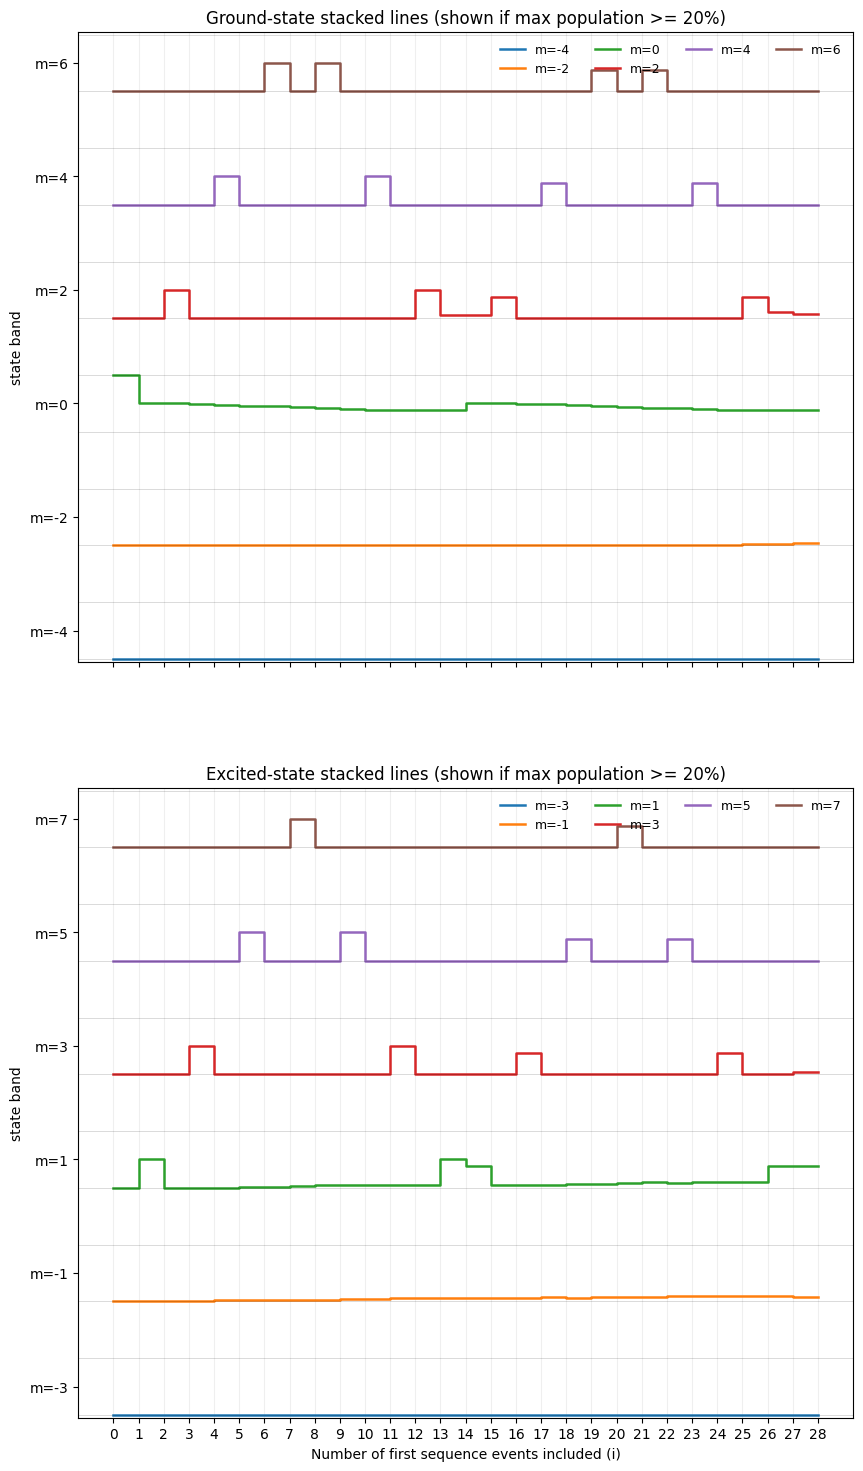

In [10]:
# Stacked line plots by m-state (population offset by m)
# For each m, y = population(m, i) + m, so m=0 spans 0..1, m=1 spans 1..2, etc.


i_vals = np.arange(n_steps)

fig, axes = plt.subplots(2, 1, figsize=(10, 18), sharex=True)


def plot_stacked_lines(ax, grid, title, threshold):
    keep_mask = grid.max(axis=1) >= threshold
    shown_m = m_all[keep_mask]

    if shown_m.size == 0:
        ax.text(
            0.5,
            0.5,
            "No m-state exceeds threshold",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )
        ax.set_title(title)
        ax.set_ylabel("offset population = m + pop")
        return

    for m in shown_m:
        row = np.where(m_all == m)[0][0]
        y = grid[row, :] + m
        ax.step(i_vals, y, where="post", lw=1.8, label=f"m={m}")

    # Horizontal guides at integer band boundaries
    y_min = int(np.min(shown_m))
    y_max = int(np.max(shown_m)) + 1
    for y0 in range(y_min, y_max + 1):
        ax.axhline(y0, color="k", lw=0.5, alpha=0.2)

    # Label each m band at its center (m + 0.5)
    ax.set_yticks(shown_m + 0.5)
    ax.set_yticklabels([f"m={m}" for m in shown_m])
    ax.set_ylim(y_min - 0.05, y_max + 0.05)

    ax.set_title(title)
    ax.set_ylabel("state band")
    ax.grid(alpha=0.2, axis="x")
    ax.legend(ncol=4, fontsize=9, frameon=False, loc="upper right")


plot_stacked_lines(
    axes[0],
    grid_g,
    "Ground-state stacked lines (shown if max population >= 20%)",
    threshold
)
plot_stacked_lines(
    axes[1],
    grid_e,
    "Excited-state stacked lines (shown if max population >= 20%)",
    threshold
)

axes[1].set_xlabel("Number of first sequence events included (i)")
axes[1].set_xticks(i_vals);

Ah, it's just legit physics. Cool!